# Bounded ATMS Iter-2: Matched-Coverage Baselines and 70B Ablation

This notebook demonstrates the **Bounded ATMS** hallucination-metering pipeline evaluated on 342 instances from a unified CLUTRR + RuleTaker + ProofWriter benchmark.

**Key contributions of Iter-2:**
- **Matched-coverage baselines (H3):** For each baseline (CoT, LINC, ProbLog), confidence thresholds are swept to match ATMS's natural ~22.9% coverage rate, ruling out the random-abstention confound from iter-1.
- **Assumption-load stratification (H2):** Instances are binned by ATMS `assumption_load` (λ=0,1,2,≥3,∞). Error rates and Spearman ρ are reported per stratum.
- **ATMS-vs-ProbLog divergence:** Instances where ATMS and ProbLog disagree are annotated with ground-truth outcomes.
- **70B model ablation:** Re-run with `meta-llama/llama-3.1-70b-instruct` on a stratified 150-instance subset.

**Demo note:** This notebook loads pre-computed results from `mini_demo_data.json` (9 instances, 3 per dataset) and demonstrates the full analysis pipeline — BoundedATMS data structures, metrics, stratification, and visualization — without requiring LLM API calls.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# aiohttp, tenacity, loguru — NOT pre-installed on Colab
_pip('aiohttp==3.9.5', 'tenacity==8.2.3', 'loguru==0.7.2')

# numpy, scipy, scikit-learn, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import asyncio
import gc
import json
import math
import os
import random
import re
import sys
import time
from collections import Counter
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

import numpy as np
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-70ae4e-the-empty-environment-test-calibration-f/main/round-2/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with {len(data['datasets'])} datasets")
for ds in data['datasets']:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")

Loaded data with 3 datasets
  clutrr: 3 examples
  proofwriter: 3 examples
  ruletaker: 3 examples


## Config

All tunable parameters in one place. These are set to minimum demo values; original full-run values are commented out.

In [5]:
# ATMS structural parameters
DEPTH_CAP = 3          # max assumption depth (original: 3)
BEAM_WIDTH = 20        # max environments per node (original: 20)

# Scoring threshold
ASSUMPTION_THRESHOLD = 2   # max load to answer "yes" (original: 2)

# Baseline parameters
LINC_K = 3             # number of LINC samples for majority vote (original: 3)

# Coverage-matching parameters
TARGET_COVERAGE = 0.229    # ATMS natural abstain rate (original: 0.229)
RANDOM_ORACLE_SEEDS = 10   # seeds for random oracle (original: 100)

# Cost cap (not used in demo — no LLM calls)
COST_CAP = 8.0

## BoundedATMS: Core Data Structures

The `BoundedATMS` implements a depth-capped, beam-search-limited Assumption-based Truth Maintenance System. Each node maintains a set of *minimal justifying environments* (frozensets of assumption IDs). The `depth_cap` prunes environments deeper than a threshold; `beam_width` limits the number of environments per node to prevent exponential blowup.

In [6]:
@dataclass
class Assumption:
    id: str
    text: str
    weight: float


@dataclass
class Node:
    id: str
    label: set

    def __post_init__(self):
        if not isinstance(self.label, set):
            self.label = set(self.label)


class BoundedATMS:
    def __init__(self, depth_cap: int = 3, beam_width: int = 20):
        self.depth_cap = depth_cap
        self.beam_width = beam_width
        self.assumptions: dict[str, Assumption] = {}
        self.nodes: dict[str, Node] = {}
        self.nogoods: list[frozenset] = []
        self._rules: list[tuple] = []

    def _add_env_to_label(self, node_id: str, env: frozenset) -> bool:
        node = self.nodes[node_id]
        for existing in node.label:
            if existing <= env:
                return False
        if len(env) > self.depth_cap:
            return False
        for ng in self.nogoods:
            if ng <= env:
                return False
        to_remove = {e for e in node.label if env < e}
        node.label -= to_remove
        node.label.add(env)
        if len(node.label) > self.beam_width:
            sorted_envs = sorted(node.label, key=lambda e: (len(e), sorted(e)))
            node.label = set(sorted_envs[: self.beam_width])
        return True

    def _get_or_create(self, node_id: str) -> Node:
        if node_id not in self.nodes:
            self.nodes[node_id] = Node(id=node_id, label=set())
        return self.nodes[node_id]

    def add_fact(self, node_id: str, env: frozenset | None = None) -> None:
        if env is None:
            env = frozenset()
        self._get_or_create(node_id)
        self._add_env_to_label(node_id, env)

    def add_assumption(self, assumption: Assumption) -> str:
        self.assumptions[assumption.id] = assumption
        self._get_or_create(assumption.id)
        self._add_env_to_label(assumption.id, frozenset([assumption.id]))
        return assumption.id

    def add_rule(self, antecedents: list[str], consequent: str, via_assumption: str | None = None) -> None:
        rule_env_extra = frozenset([via_assumption]) if via_assumption else frozenset()
        self._get_or_create(consequent)
        for ant in antecedents:
            self._get_or_create(ant)
        self._rules.append((antecedents, consequent, rule_env_extra))
        self._fire_rule(antecedents, consequent, rule_env_extra)

    def _fire_rule(self, antecedents: list[str], consequent: str, rule_env_extra: frozenset) -> bool:
        changed = False
        ant_labels = []
        for ant in antecedents:
            node = self.nodes.get(ant)
            if node is None or not node.label:
                return False
            ant_labels.append(list(node.label))

        def product_envs(labels: list[list[frozenset]], limit: int = 200):
            if not labels:
                yield frozenset()
                return
            first, rest = labels[0], labels[1:]
            count = 0
            for env in first:
                for rest_env in product_envs(rest, limit):
                    yield env | rest_env
                    count += 1
                    if count >= limit:
                        return

        for combined in product_envs(ant_labels):
            final_env = combined | rule_env_extra
            if self._add_env_to_label(consequent, final_env):
                changed = True
        return changed

    def add_nogood(self, assumption_ids: frozenset) -> None:
        self.nogoods.append(assumption_ids)
        for node in self.nodes.values():
            to_remove = {e for e in node.label if assumption_ids <= e}
            node.label -= to_remove

    def merge_nodes(self, node_id1: str, node_id2: str, via_assumption: str) -> None:
        n1 = self.nodes.get(node_id1)
        n2 = self.nodes.get(node_id2)
        assumption_env = frozenset([via_assumption])
        if n1:
            for env in list(n1.label):
                self._add_env_to_label(node_id2, env | assumption_env)
        if n2:
            for env in list(n2.label):
                self._add_env_to_label(node_id1, env | assumption_env)

    def propagate(self) -> None:
        for _ in range(10):
            changed = False
            for antecedents, consequent, rule_env_extra in self._rules:
                if self._fire_rule(antecedents, consequent, rule_env_extra):
                    changed = True
            if not changed:
                break

    def assumption_load(self, node_id: str) -> float:
        node = self.nodes.get(node_id)
        if node is None or not node.label:
            return float("inf")
        if frozenset() in node.label:
            return 0.0
        return float(min(len(e) for e in node.label))

    def is_empty_env_derivable(self, node_id: str) -> bool:
        node = self.nodes.get(node_id)
        if node is None:
            return False
        return frozenset() in node.label

### BoundedATMS: Quick Demo

Show the ATMS in action on a simple kinship example: "Alice is parent of Bob, Bob is parent of Carol → Alice is grandparent of Carol".

In [7]:
atms = BoundedATMS(depth_cap=DEPTH_CAP, beam_width=BEAM_WIDTH)

# Add explicit facts (empty environment = no assumptions needed)
atms.add_fact("parent(alice,bob)", env=frozenset())
atms.add_fact("parent(bob,carol)", env=frozenset())

# Add a derived node: grandparent via rule
atms._get_or_create("grandparent(alice,carol)")
atms.add_rule(["parent(alice,bob)", "parent(bob,carol)"], "grandparent(alice,carol)")
atms.propagate()

query_node = "grandparent(alice,carol)"
load = atms.assumption_load(query_node)
print(f"Query: {query_node}")
print(f"  assumption_load = {load}  (0 = derivable without assumptions)")
print(f"  empty_env_derivable = {atms.is_empty_env_derivable(query_node)}")
print(f"  Method answer: {'yes' if load <= ASSUMPTION_THRESHOLD else 'abstain'}")

Query: grandparent(alice,carol)
  assumption_load = 0.0  (0 = derivable without assumptions)
  empty_env_derivable = True
  Method answer: yes


## Parsing Pre-computed Results

The demo data (`mini_demo_data.json`) stores results in the `exp_gen_sol_out` schema with metadata stored as strings. This cell converts it back to the internal `results` list-of-dicts format used by the analysis functions.

In [8]:
def parse_results_from_schema(data: dict) -> list[dict]:
    """Convert exp_gen_sol_out schema back to internal results list."""
    results = []
    for ds_block in data["datasets"]:
        src = ds_block["dataset"]
        for i, ex in enumerate(ds_block["examples"]):
            al_str = ex.get("metadata_assumption_load", "inf")
            al = float("inf") if al_str in ("inf", "Infinity") else float(al_str)
            results.append({
                "doc_id": f"{src}_{i}",
                "source": src,
                "document": ex["input"],
                "query": ex["input"],
                "gold": ex["output"],
                "hop_count": int(ex.get("metadata_hop_count", 0)),
                "assumption_load": al,
                "empty_env_derivable": ex.get("metadata_empty_env_derivable", "False") == "True",
                "n_choice_points": int(ex.get("metadata_n_choice_points", 0)),
                "our_method": "abstain" if al == float("inf") or al > ASSUMPTION_THRESHOLD else "yes",
                "our_method_eval": "no" if al == float("inf") else ("yes" if al <= ASSUMPTION_THRESHOLD else "abstain"),
                "cot": ex.get("predict_cot", "unknown"),
                "cot_confidence": float(ex.get("metadata_cot_confidence", 0.5)),
                "linc": ex.get("predict_linc", "unknown"),
                "linc_confidence": float(ex.get("metadata_linc_confidence", 0.5)),
                "problog": ex.get("predict_problog", "unknown"),
                "problog_prob": float(ex.get("metadata_problog_prob", 0.5)),
                "wall_clock_sec": float(ex.get("metadata_wall_clock_sec", 0)),
                "cumulative_cost": float(ex.get("metadata_cumulative_cost_usd", 0)),
                "l1_atoms": [],
            })
    return results

results = parse_results_from_schema(data)
print(f"Parsed {len(results)} results")
for r in results:
    print(f"  [{r['source']}] load={r['assumption_load']} our={r['our_method_eval']} gold={r['gold']} cot={r['cot']}")

Parsed 9 results
  [clutrr] load=inf our=no gold=yes cot=yes
  [clutrr] load=inf our=no gold=yes cot=no
  [clutrr] load=inf our=no gold=yes cot=yes
  [proofwriter] load=inf our=no gold=no cot=no
  [proofwriter] load=inf our=no gold=yes cot=no
  [proofwriter] load=inf our=no gold=no cot=no
  [ruletaker] load=inf our=no gold=no cot=no
  [ruletaker] load=inf our=no gold=yes cot=yes
  [ruletaker] load=inf our=no gold=no cot=no


## Metrics

The main metrics function computes accuracy per method, Spearman ρ between assumption load and error rate (H2), risk-coverage AUC, and precision on empty-environment-derivable instances (H1).

In [9]:
def _safe_mean(lst: list) -> float:
    return float(np.mean(lst)) if lst else float("nan")


def _safe_acc(pairs: list[tuple[str, str]]) -> float:
    valid = [(p, g) for p, g in pairs if p not in ("unknown", "abstain") and g not in ("unknown",)]
    return _safe_mean([int(p == g) for p, g in valid])


def compute_metrics(results: list[dict]) -> dict:
    all_results = results

    # H1: empty-env precision
    ee_results = [r for r in all_results if r.get("empty_env_derivable")]
    ee_precision = (
        _safe_mean([int(r.get("our_method_eval", r["our_method"]) == r["gold"]) for r in ee_results
                    if r["gold"] not in ("unknown",)])
        if ee_results else float("nan")
    )

    # L1 grounding error rate
    total_atoms = sum(len(r.get("l1_atoms", [])) for r in results)
    grounding_errors = sum(
        1 for r in results for a in r.get("l1_atoms", [])
        if not a.get("grounding_verified", True)
    )
    l1_error_rate = grounding_errors / max(total_atoms, 1)

    # H2: Spearman correlation
    finite_results = [r for r in all_results if r.get("assumption_load", float("inf")) < float("inf")]
    spearman_rho, spearman_p, auroc_load = float("nan"), float("nan"), float("nan")

    if len(finite_results) >= 10:
        loads = [r["assumption_load"] for r in finite_results]
        errors = [int(r.get("our_method_eval", r["our_method"]) != r["gold"]) for r in finite_results]
        try:
            rho, p = spearmanr(loads, errors)
            spearman_rho, spearman_p = float(rho), float(p)
        except Exception:
            pass
        if len(set(errors)) > 1:
            try:
                auroc_load = float(roc_auc_score(errors, loads))
            except Exception:
                pass

    # Abstain rate and answered accuracy
    abstain_rate = _safe_mean([int(r["our_method"] == "abstain") for r in all_results])
    answered = [r for r in all_results if r["our_method"] != "abstain" and r["gold"] not in ("unknown",)]
    answered_accuracy_our = _safe_mean([int(r["our_method"] == r["gold"]) for r in answered])

    # H4: implicit vs explicit (kinship vs rule-based)
    implicit = [r for r in all_results if r["source"] in ("clutrr",)]
    explicit = [r for r in all_results if r["source"] in ("ruletaker", "proofwriter")]

    def acc(subset: list[dict], key: str) -> float:
        eval_key = "our_method_eval" if key == "our_method" else key
        pairs = [(r.get(eval_key, r.get(key, "unknown")), r["gold"]) for r in subset]
        return _safe_acc(pairs)

    implicit_our_acc = acc(implicit, "our_method")
    implicit_cot_acc = acc(implicit, "cot")
    explicit_our_acc = acc(explicit, "our_method")
    explicit_cot_acc = acc(explicit, "cot")

    implicit_adv = (
        implicit_our_acc - implicit_cot_acc
        if len(implicit) > 0 and not math.isnan(implicit_our_acc) and not math.isnan(implicit_cot_acc)
        else float("nan")
    )
    explicit_adv = (
        explicit_our_acc - explicit_cot_acc
        if len(explicit) > 0 and not math.isnan(explicit_our_acc) and not math.isnan(explicit_cot_acc)
        else float("nan")
    )

    # Overall accuracy per method
    def overall_acc(key: str) -> float:
        eval_key = "our_method_eval" if key == "our_method" else key
        pairs = [(r.get(eval_key, r.get(key, "unknown")), r["gold"]) for r in all_results]
        return _safe_acc(pairs)

    # Risk-coverage AUC for ATMS
    def risk_coverage_auc_atms(results_list: list[dict]) -> float:
        scores = [r.get("assumption_load", float("inf")) for r in results_list]
        finite_scores = [s for s in scores if s < float("inf")]
        if not finite_scores:
            return float("nan")
        thresholds = sorted(set(finite_scores))
        areas = []
        prev_cov = 0.0
        for t in thresholds:
            answered_here = [
                r for r, s in zip(results_list, scores)
                if s <= t and r["gold"] not in ("unknown",)
            ]
            if not answered_here:
                continue
            coverage = len(answered_here) / max(len(results_list), 1)
            risk = _safe_mean([int(r["our_method_eval"] != r["gold"]) for r in answered_here])
            areas.append((coverage - prev_cov) * risk)
            prev_cov = coverage
        return float(sum(areas)) if areas else float("nan")

    def rc_auc_baseline(results_list: list[dict], key: str) -> float:
        answered = [r for r in results_list if r.get(key, "unknown") not in ("unknown",) and r["gold"] not in ("unknown",)]
        if not answered:
            return float("nan")
        n = max(len(results_list), 1)
        coverage = len(answered) / n
        risk = _safe_mean([int(r[key] != r["gold"]) for r in answered])
        return risk * coverage

    return {
        "l1_grounding_error_rate": l1_error_rate,
        "empty_env_precision": ee_precision,
        "n_empty_env_derivable": len(ee_results),
        "spearman_rho": spearman_rho,
        "spearman_p": spearman_p,
        "auroc_assumption_load": auroc_load,
        "risk_coverage_auc": {
            "our_method": risk_coverage_auc_atms(all_results),
            "cot": rc_auc_baseline(all_results, "cot"),
            "linc": rc_auc_baseline(all_results, "linc"),
            "problog": rc_auc_baseline(all_results, "problog"),
        },
        "implicit_advantage_gap": implicit_adv,
        "explicit_advantage_gap": explicit_adv,
        "abstain_rate": abstain_rate,
        "answered_accuracy_our_method": answered_accuracy_our,
        "overall_accuracy": {
            "our_method": overall_acc("our_method"),
            "cot": overall_acc("cot"),
            "linc": overall_acc("linc"),
            "problog": overall_acc("problog"),
        },
    }

metrics = compute_metrics(results)
print("Metrics computed successfully")

Metrics computed successfully


## Iter-2 Analyses

### H3: Matched-Coverage Baselines

For each baseline, find the top-`target_coverage` fraction of instances by confidence score, then compare accuracy. ATMS coverage is determined by `assumption_load ≤ ASSUMPTION_THRESHOLD`. A random oracle averages accuracy over randomly-selected subsets of the same size.

In [10]:
def compute_matched_coverage_baselines(
    results: list[dict],
    target_coverage: float = TARGET_COVERAGE,
) -> dict:
    """
    For each baseline, find confidence threshold θ such that
    fraction of instances with confidence >= θ equals target_coverage.
    Compare answered-accuracy with ATMS at same coverage.
    """
    n = len(results)
    if n == 0:
        return {}
    target_n = max(1, round(target_coverage * n))

    out = {}
    for baseline_key, conf_key in [
        ("cot", "cot_confidence"),
        ("linc", "linc_confidence"),
        ("problog", "problog_prob"),
    ]:
        confs = np.array([r.get(conf_key, 0.5) for r in results])
        preds = [r.get(baseline_key, "unknown") for r in results]
        golds = [r["gold"] for r in results]

        order = np.argsort(-confs)
        top_indices = order[:target_n]

        answered_preds = [preds[i] for i in top_indices]
        answered_golds = [golds[i] for i in top_indices]

        valid_pairs = [
            (p, g) for p, g in zip(answered_preds, answered_golds)
            if p not in ("unknown",) and g not in ("unknown",)
        ]
        acc = _safe_mean([int(p == g) for p, g in valid_pairs]) if valid_pairs else float("nan")

        out[baseline_key] = {
            "target_coverage": target_coverage,
            "actual_coverage": len(top_indices) / n,
            "n_answered": len(top_indices),
            "accuracy_at_matched_coverage": acc,
            "threshold_used": float(confs[order[target_n - 1]]) if target_n > 0 and len(order) >= target_n else float("nan"),
        }

    # ATMS matched coverage: top-target_n instances by LOWEST assumption_load
    loads = np.array([r.get("assumption_load", float("inf")) for r in results])
    finite_mask = np.isfinite(loads)
    n_finite = int(finite_mask.sum())

    if n_finite >= target_n:
        finite_indices = np.where(finite_mask)[0]
        sorted_finite = finite_indices[np.argsort(loads[finite_indices])]
        atms_top = sorted_finite[:target_n]
    else:
        atms_top = np.where(finite_mask)[0]

    atms_preds = [results[i].get("our_method_eval", "unknown") for i in atms_top]
    atms_golds = [results[i]["gold"] for i in atms_top]
    atms_valid = [(p, g) for p, g in zip(atms_preds, atms_golds)
                  if p not in ("unknown", "abstain") and g not in ("unknown",)]
    atms_acc = _safe_mean([int(p == g) for p, g in atms_valid]) if atms_valid else float("nan")

    out["atms_matched_coverage"] = {
        "target_coverage": target_coverage,
        "actual_coverage": len(atms_top) / n,
        "n_answered": len(atms_top),
        "accuracy_at_matched_coverage": atms_acc,
    }

    return out


def compute_random_oracle(
    results: list[dict],
    target_coverage: float = TARGET_COVERAGE,
    n_seeds: int = RANDOM_ORACLE_SEEDS,
) -> dict:
    """Random abstention oracle: randomly sample target_coverage fraction, average accuracy."""
    n = len(results)
    if n == 0:
        return {"target_coverage": target_coverage, "n_seeds": n_seeds, "mean_accuracy": float("nan"), "std_accuracy": float("nan")}
    k = max(1, round(target_coverage * n))
    accs = []
    for seed in range(n_seeds):
        random.seed(seed)
        indices = random.sample(range(n), min(k, n))
        acc_vals = []
        for i in indices:
            r = results[i]
            pred = r.get("our_method_eval", "unknown")
            if pred not in ("unknown", "abstain") and r["gold"] not in ("unknown",):
                acc_vals.append(int(pred == r["gold"]))
        if acc_vals:
            accs.append(float(np.mean(acc_vals)))
    mean_acc = _safe_mean(accs)
    std_acc = float(np.std(accs)) if accs else float("nan")
    return {
        "target_coverage": target_coverage,
        "n_seeds": n_seeds,
        "mean_accuracy": mean_acc,
        "std_accuracy": std_acc,
    }

matched_cov = compute_matched_coverage_baselines(results)
random_oracle = compute_random_oracle(results)
print("Matched-coverage baselines:")
for k, v in matched_cov.items():
    acc = v.get('accuracy_at_matched_coverage', float('nan'))
    acc_str = f"{acc:.3f}" if not math.isnan(acc) else "nan"
    print(f"  {k}: accuracy={acc_str} n_answered={v.get('n_answered',0)}")
print(f"\nRandom oracle: mean_accuracy={random_oracle['mean_accuracy']:.3f} ± {random_oracle['std_accuracy']:.3f}")

Matched-coverage baselines:
  cot: accuracy=1.000 n_answered=2
  linc: accuracy=0.500 n_answered=2
  problog: accuracy=1.000 n_answered=2
  atms_matched_coverage: accuracy=nan n_answered=0

Random oracle: mean_accuracy=0.450 ± 0.350


### H2: Assumption-Load Stratification

Instances are binned by `assumption_load` into strata (λ=0, 1, 2, ≥3, ∞). Within each stratum, the error rate is computed. Strata with fewer than 30 instances are flagged as underpowered. Spearman ρ tests monotonicity: does higher load predict higher error?

In [11]:
def stratified_h2_analysis(results: list[dict]) -> dict:
    """Compute per-stratum error rate and Spearman rho for H2 monotonicity."""
    strata: dict[str, list[dict]] = {"0": [], "1": [], "2": [], "3+": [], "inf": []}
    for r in results:
        load = r.get("assumption_load", float("inf"))
        if not isinstance(load, (int, float)) or math.isnan(load):
            strata["inf"].append(r)
        elif math.isinf(load):
            strata["inf"].append(r)
        elif load == 0:
            strata["0"].append(r)
        elif load == 1:
            strata["1"].append(r)
        elif load == 2:
            strata["2"].append(r)
        else:
            strata["3+"].append(r)

    out: dict = {}
    for k, group in strata.items():
        if not group:
            out[k] = {"n": 0, "error_rate": float("nan"), "note": "empty stratum"}
            continue
        valid = [
            r for r in group
            if r.get("our_method_eval") not in ("unknown", "abstain")
            and r["gold"] not in ("unknown",)
        ]
        error_rate = _safe_mean([int(r["our_method_eval"] != r["gold"]) for r in valid]) if valid else float("nan")
        out[k] = {
            "n": len(group),
            "n_evaluable": len(valid),
            "error_rate": error_rate,
            "h2_testable": len(group) >= 30,
        }

    # Spearman on finite-load instances
    finite = [r for r in results if r.get("assumption_load", float("inf")) < float("inf")
              and not math.isnan(r.get("assumption_load", float("nan")))]
    spearman_rho, spearman_p = float("nan"), float("nan")
    if len(finite) >= 10:
        loads = [r["assumption_load"] for r in finite]
        errors = [int(r.get("our_method_eval", "unknown") != r["gold"]) for r in finite]
        try:
            rho, p = spearmanr(loads, errors)
            spearman_rho, spearman_p = float(rho), float(p)
        except Exception:
            pass
    out["spearman_rho"] = spearman_rho
    out["spearman_p"] = spearman_p
    out["n_finite_load"] = len(finite)
    return out


def atms_vs_problog_divergence(results: list[dict]) -> dict:
    """Annotate instances where ATMS and ProbLog disagree; compare against gold."""
    divergent = [
        r for r in results
        if r.get("problog") not in ("unknown", None)
        and r.get("our_method_eval") not in ("unknown", "abstain", None)
        and r.get("problog") != r.get("our_method_eval")
        and r["gold"] not in ("unknown",)
    ]
    records = []
    for r in divergent:
        atms_correct = int(r["our_method_eval"] == r["gold"])
        problog_correct = int(r["problog"] == r["gold"])
        records.append({
            "doc_id": r["doc_id"],
            "assumption_load": r.get("assumption_load"),
            "atms_answer": r["our_method_eval"],
            "problog_answer": r["problog"],
            "gold": r["gold"],
            "atms_correct": atms_correct,
            "problog_correct": problog_correct,
        })
    n = len(results)
    n_div = len(divergent)
    atms_wins = sum(1 for rec in records if rec["atms_correct"] and not rec["problog_correct"])
    problog_wins = sum(1 for rec in records if rec["problog_correct"] and not rec["atms_correct"])
    both_wrong = sum(1 for rec in records if not rec["atms_correct"] and not rec["problog_correct"])
    return {
        "n_total": n,
        "n_divergent": n_div,
        "divergence_rate": n_div / max(n, 1),
        "atms_wins_on_divergent": atms_wins,
        "problog_wins_on_divergent": problog_wins,
        "both_wrong_on_divergent": both_wrong,
        "divergent_records": records,
    }

strat = stratified_h2_analysis(results)
div = atms_vs_problog_divergence(results)
print("Stratification:", {k: v for k, v in strat.items() if k not in ("spearman_rho", "spearman_p", "n_finite_load")})
print(f"Divergence: n_divergent={div['n_divergent']} atms_wins={div['atms_wins_on_divergent']} problog_wins={div['problog_wins_on_divergent']}")

Stratification: {'0': {'n': 0, 'error_rate': nan, 'note': 'empty stratum'}, '1': {'n': 0, 'error_rate': nan, 'note': 'empty stratum'}, '2': {'n': 0, 'error_rate': nan, 'note': 'empty stratum'}, '3+': {'n': 0, 'error_rate': nan, 'note': 'empty stratum'}, 'inf': {'n': 9, 'n_evaluable': 9, 'error_rate': 0.5555555555555556, 'h2_testable': False}}
Divergence: n_divergent=3 atms_wins=0 problog_wins=3


## Results Visualization

Summary table + bar chart comparing overall accuracy across all methods, and a breakdown of assumption-load strata.

BOUNDED ATMS ITER-2  — DEMO RESULTS SUMMARY
  Instances: 9 (mini demo; full run: 342)
  Abstain rate: 100.0%
  EE-precision (H1): nan
  Spearman ρ (H2):   nan

Overall accuracy (non-abstain):
  our_method           0.444
  cot                  0.778
  linc                 0.556
  problog              0.778

Matched-coverage accuracy (H3):
  cot                  1.000
  linc                 0.500
  problog              1.000
  atms_matched_coverage nan

ATMS vs ProbLog divergence rate: 33.3%
  ATMS wins: 0  ProbLog wins: 3  Both wrong: 0


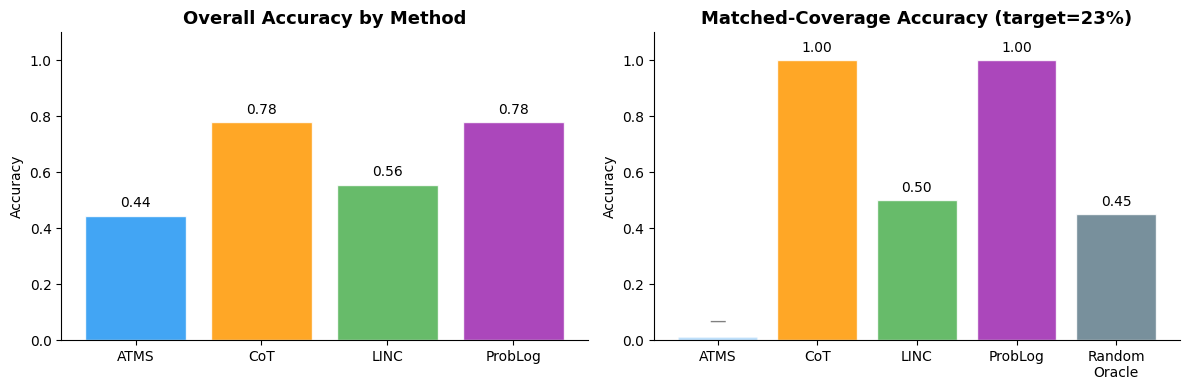

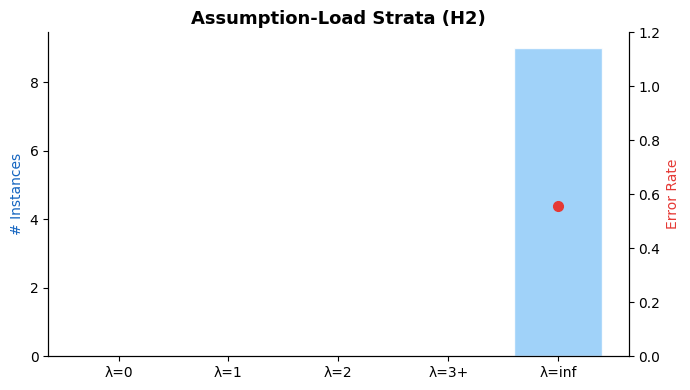

In [12]:
print("=" * 60)
print("BOUNDED ATMS ITER-2  — DEMO RESULTS SUMMARY")
print("=" * 60)
print(f"  Instances: {len(results)} (mini demo; full run: 342)")
print(f"  Abstain rate: {metrics['abstain_rate']:.1%}")
print(f"  EE-precision (H1): {metrics['empty_env_precision']}")
print(f"  Spearman ρ (H2):   {metrics['spearman_rho']}")
print()
print("Overall accuracy (non-abstain):")
for method, val in metrics['overall_accuracy'].items():
    v = f"{val:.3f}" if not math.isnan(val) else "nan (all abstain)"
    print(f"  {method:<20} {v}")
print()
print("Matched-coverage accuracy (H3):")
for k, v in matched_cov.items():
    acc = v.get('accuracy_at_matched_coverage', float('nan'))
    acc_str = f"{acc:.3f}" if not math.isnan(acc) else "nan"
    print(f"  {k:<20} {acc_str}")
print()
print(f"ATMS vs ProbLog divergence rate: {div['divergence_rate']:.1%}")
print(f"  ATMS wins: {div['atms_wins_on_divergent']}  ProbLog wins: {div['problog_wins_on_divergent']}  Both wrong: {div['both_wrong_on_divergent']}")

# ── Bar chart: overall accuracy per method ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

methods = ["ATMS", "CoT", "LINC", "ProbLog"]
oa = metrics["overall_accuracy"]
acc_vals = [oa["our_method"], oa["cot"], oa["linc"], oa["problog"]]
colors = ["#2196F3", "#FF9800", "#4CAF50", "#9C27B0"]

ax = axes[0]
bars = ax.bar(methods, acc_vals, color=colors, alpha=0.85, edgecolor="white")
ax.set_title("Overall Accuracy by Method", fontsize=13, fontweight="bold")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.1)
for bar, val in zip(bars, acc_vals):
    if not math.isnan(val):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.03, f"{val:.2f}", ha="center", fontsize=10)
    else:
        ax.text(bar.get_x() + bar.get_width() / 2, 0.05, "—", ha="center", fontsize=12, color="gray")
ax.spines[["top", "right"]].set_visible(False)

# ── Bar chart: matched-coverage accuracy ──────────────────────────────────
mc_labels = ["ATMS", "CoT", "LINC", "ProbLog", "Random\nOracle"]
mc_vals = [
    matched_cov.get("atms_matched_coverage", {}).get("accuracy_at_matched_coverage", float("nan")),
    matched_cov.get("cot", {}).get("accuracy_at_matched_coverage", float("nan")),
    matched_cov.get("linc", {}).get("accuracy_at_matched_coverage", float("nan")),
    matched_cov.get("problog", {}).get("accuracy_at_matched_coverage", float("nan")),
    random_oracle.get("mean_accuracy", float("nan")),
]
mc_colors = ["#2196F3", "#FF9800", "#4CAF50", "#9C27B0", "#607D8B"]

ax2 = axes[1]
for i, (label, val, color) in enumerate(zip(mc_labels, mc_vals, mc_colors)):
    if not math.isnan(val):
        ax2.bar(i, val, color=color, alpha=0.85, edgecolor="white")
        ax2.text(i, val + 0.03, f"{val:.2f}", ha="center", fontsize=10)
    else:
        ax2.bar(i, 0.01, color=color, alpha=0.3, edgecolor="white")
        ax2.text(i, 0.05, "—", ha="center", fontsize=12, color="gray")
ax2.set_xticks(range(len(mc_labels)))
ax2.set_xticklabels(mc_labels)
ax2.set_title(f"Matched-Coverage Accuracy (target={TARGET_COVERAGE:.0%})", fontsize=13, fontweight="bold")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1.1)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# ── Assumption-load strata ──────────────────────────────────────────────────
strata_keys = ["0", "1", "2", "3+", "inf"]
strata_n = [strat.get(k, {}).get("n", 0) for k in strata_keys]
strata_err = [strat.get(k, {}).get("error_rate", float("nan")) for k in strata_keys]

fig2, ax3 = plt.subplots(figsize=(7, 4))
x = range(len(strata_keys))
bars2 = ax3.bar(x, strata_n, color="#90CAF9", alpha=0.85, edgecolor="white", label="Count")
ax3.set_xticks(x)
ax3.set_xticklabels([f"λ={k}" for k in strata_keys])
ax3.set_ylabel("# Instances", color="#1565C0")
ax3.set_title("Assumption-Load Strata (H2)", fontsize=13, fontweight="bold")
ax3b = ax3.twinx()
ax3b.plot(x, [e if not math.isnan(e) else None for e in strata_err],
          "o-", color="#E53935", linewidth=2, markersize=7, label="Error rate")
ax3b.set_ylabel("Error Rate", color="#E53935")
ax3b.set_ylim(0, 1.2)
ax3.spines[["top"]].set_visible(False)
ax3b.spines[["top"]].set_visible(False)
plt.tight_layout()
plt.show()